# Notebook for all simulations

In [ ]:
# %load_ext autoreload
# %autoreload 2

In [1]:
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

from check_warmup import avg_warmup_count, plot_avg_warmup_count

from environment import GLMBandit

from glmbanditexp.algorithms.ecolog import EcoLog
from glmbanditexp.algorithms.gloc import Gloc
from glmbanditexp.algorithms.glm_ucb import GlmUCB
from glmbanditexp.algorithms.rs_glinucb import RS_GLinUCB
from glmbanditexp.algorithms.private_rs_glinucb import Private_RS_GLinUCB
from glmbanditexp.algorithms.ofulogplus import OFULogPlus

### Warm-up Count for Rarely-Switching GLBandit

In [2]:
num_trials = 5
d=5
K=10
T=5000
kappa=50.0
R=1.0
S=5.0
lmbda=20.0
seed=186329

Running trial 1


100%|██████████| 5000/5000 [00:00<00:00, 20693.97it/s]


Running trial 2


100%|██████████| 5000/5000 [00:00<00:00, 21616.29it/s]


Running trial 3


100%|██████████| 5000/5000 [00:00<00:00, 20675.10it/s]


Running trial 4


100%|██████████| 5000/5000 [00:00<00:00, 17097.58it/s]


Running trial 5


100%|██████████| 5000/5000 [00:00<00:00, 21469.99it/s]


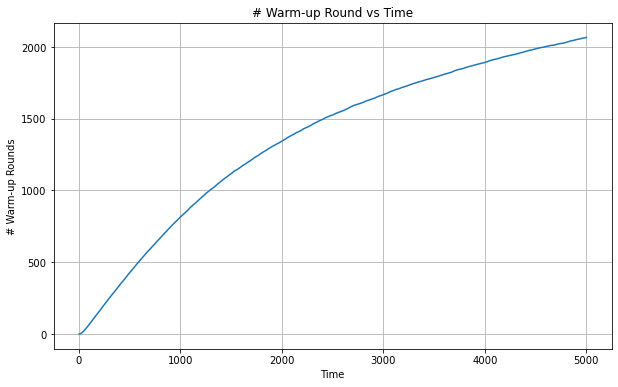

In [3]:
count = avg_warmup_count(num_trials, d, K, T, kappa, R, S, lmbda, seed)
plot_avg_warmup_count(count, show_flag=True)

## Regret Simulations

In [4]:
# Modified simulate function with epsilon array support
def simulate_with_epsilon(num_trials, env, algo_names_list, delta, epsilon_arr=[8, 6, 4, 2], seed=None):
    regret_dict = {}
    # Create a single rng for all trials
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()
        
    for n in range(num_trials):
        algo_arr = []
        algo_eps_mapping = []  # Track which epsilon each algorithm uses
        print('Simulating trial', n+1)
        for k in algo_names_list:
            if k == 'Private-GLM':
                # Create multiple Private-RS-GLinUCB instances with different epsilon values
                for eps in epsilon_arr:
                    algo = Private_RS_GLinUCB(env.get_first_action_set(), env.kappa, env.kappa_star, 
                                           env.R, env.S, env.model, env.T, delta, eps, 2e-2, rng=rng)
                    algo_arr.append(algo)
                    algo_eps_mapping.append(eps)  # Track the epsilon for this algorithm
            elif k == 'RS-GLinUCB':
                algo = RS_GLinUCB(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, env.T, delta, rng=rng)
                algo_arr.append(algo)
                algo_eps_mapping.append(None)  # No epsilon for non-private algorithms
            elif k == 'GLOC':
                algo = Gloc(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, delta, rng=rng)
                algo_arr.append(algo)
                algo_eps_mapping.append(None)
            elif k == 'GLM-UCB':
                algo = GlmUCB(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, env.T, delta, rng=rng)
                algo_arr.append(algo)
                algo_eps_mapping.append(None)
            elif k == 'EcoLog':
                algo = EcoLog(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, delta, rng=rng)
                algo_arr.append(algo)
                algo_eps_mapping.append(None)
            elif k == 'OfuLog+':
                algo = OFULogPlus(env.get_first_action_set(), env.kappa, env.R, env.S, env.model, env.T, delta, rng=rng)
                algo_arr.append(algo)
                algo_eps_mapping.append(None)

        print("Algorithm mapping:")
        for j, (algo, eps) in enumerate(zip(algo_arr, algo_eps_mapping)):
            print(f"  Index {j}: {algo.name} -> ε={eps}")
    
        for t in tqdm(range(env.T)):
            act_arr = []
            for algo in algo_arr:
                act_arr.append(algo.play_arm())
            try:
                rewards, regrets, next_arm_set = env.step(act_arr)
            except:
                raise ValueError("No action  in next time step")

            for j, algo in enumerate(algo_arr):                
                algo.update(rewards[j], regrets[j], next_arm_set)
        
        # Store results for each algorithm with proper naming
        for j, algo in enumerate(algo_arr):
            # Check if this is a Private-RS-GLinUCB algorithm by checking the algorithm name
            if 'Private-GLM' in algo.name:
                # Use the tracked epsilon value
                eps = algo_eps_mapping[j]
                algo_name = f'Private-GLM (ε={eps})'
            else:
                algo_name = algo.name
            
            if algo_name not in regret_dict.keys():
                regret_dict[algo_name] = np.array(algo.regret_arr)
            else:
                regret_dict[algo_name] += np.array(algo.regret_arr)
        env.reset()
    
    for k in regret_dict.keys():
        regret_dict[k] /= num_trials
    
    return regret_dict

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_regret(rg_dict, T, filename):
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    T_arr = np.arange(1, T+1)

    # Baseline colors (use tab10, safe and distinct)
    baseline_colors = plt.cm.tab10.colors
    baseline_map = {}

    # Use a distinct colormap for Private-GLM (e.g. Set2 or Dark2)
    private_colors = plt.cm.Set2(np.linspace(0, 1, 4))
    private_markers = ['o', 's', '^', 'D']
    private_linestyles = ['-', '--', '-.', ':']

    for i, k in enumerate(sorted(rg_dict.keys())):
        if "Private-GLM" in k:
            try:
                eps = int(k.split('ε=')[1].split(')')[0])
            except Exception:
                eps = 2
            idx = (eps // 2 - 1) % 4
            ax.plot(
                T_arr, np.cumsum(rg_dict[k]),
                color=private_colors[idx],
                linestyle=private_linestyles[idx % len(private_linestyles)],
                linewidth=2,
                marker=private_markers[idx],
                markersize=4,
                markevery=max(1, T // 25),
                label=k
            )
        else:
            if k not in baseline_map:
                baseline_map[k] = baseline_colors[len(baseline_map) % len(baseline_colors)]
            ax.plot(
                T_arr, np.cumsum(rg_dict[k]),
                color=baseline_map[k],
                linestyle='-',
                linewidth=2,
                label=k
            )

    # Single clean legend (no cutoff issues)
    ax.legend(
        fontsize=11, framealpha=0.9,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0
    )

    ax.grid(True, alpha=0.3)
    ax.set_xlabel('# of Rounds', fontsize=14)
    ax.set_ylabel('Cumulative Regret', fontsize=14)
    ax.set_title('Cumulative Regret vs # of Rounds', fontsize=16)

    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()


### Logistic Model Simulation

In [6]:
config = {"full_norm": True}
config['seed'] = 109832
config['model'] = 'Logistic'
config['theta_dim'] = 5
config['num_arms'] = 20
config['theta_norm'] = 3.5
config['horizon_length'] = 15000

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)

Calculating kappa...


100%|██████████| 15000/15000 [00:00<00:00, 41477.36it/s]


Calculating kappa star...


100%|██████████| 15000/15000 [00:00<00:00, 51237.32it/s]


Kappa = 33.76245430799423
Theta = [ 0.33611642  2.07824585  0.86373033  0.29158908 -2.64326799]


Simulating trial 1
Lambda: 350.5555480657521 private rs glinucb
Count1 cutoff: 67, Count2 cutoff: 2
Lambda: 203.24175437031175 private rs glinucb
Count1 cutoff: 67, Count2 cutoff: 2
Lambda: 129.58485752259162 private rs glinucb
Count1 cutoff: 67, Count2 cutoff: 2
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024) -> ε=None
  Index 1: ECOLog (Faury et al. 2022) -> ε=None
  Index 2: GLOC (Jun et al. 2017) -> ε=None
  Index 3: Private-GLM (This work) -> ε=2
  Index 4: Private-GLM (This work) -> ε=4
  Index 5: Private-GLM (This work) -> ε=8


  4%|▎         | 529/15000 [00:04<02:02, 117.73it/s]

DP-SGD: σ = 18.9039 for ε=1.3333333333333333, δ=0.0033333333333333335, steps=50, q=1.0 noise scale 0.006988502545349453


  7%|▋         | 1020/15000 [00:08<01:49, 127.38it/s]

DP-SGD: σ = 36.8505 for ε=0.6666666666666666, δ=0.0033333333333333335, steps=50, q=1.0 noise scale 0.007190338326697203


...

DP-SGD: σ = 61.2837 for ε=0.3333333333333333, δ=0.0033333333333333335, steps=150, q=0.4868077014499643 noise scale 0.005984738774451747


 28%|██▊       | 4215/15000 [00:57<17:31, 10.26it/s]

Counter2: 2 == 2, crossing at 4208 epsilon 2 delta 0.02


100%|██████████| 15000/15000 [03:07<00:00, 79.84it/s]


Max det curr H: 31748025325626.17, Max det prev H: 28316388458113.9 epsilon 2 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 2 delta 0.02
Max det curr H: 4297243016056.611, Max det prev H: 1541690872086.1565 epsilon 4 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 4 delta 0.02
Max det curr H: 1114554590558.4712, Max det prev H: 311280143390.13306 epsilon 8 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 8 delta 0.02


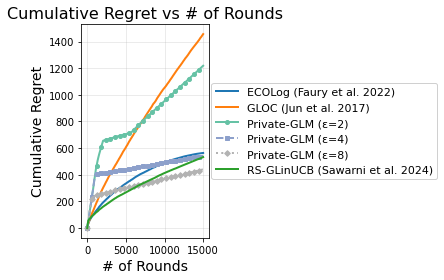

In [10]:
algo_names_list = ['RS-GLinUCB', 'EcoLog', 'GLOC', 'Private-GLM']
num_trials = 10

regret_dict = simulate_with_epsilon(num_trials, env, algo_names_list, 0.02, epsilon_arr = [2, 4, 8], seed=109832)
with open('./Results/experiment_logistic_uniform_split.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Logistic_Regret.png')
##plot_regret(regret_dict, env.T, './Results/Logistic_Regret.png')

### Probit Model Simulation

In [5]:
config = {}
config['seed'] = 109832
config['model'] = 'Probit'
config['theta_dim'] = 5
config['num_arms'] = 20
config['theta_norm'] = 3.0
config['horizon_length'] = 5000
config['full_norm'] = True

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)

Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 58672.26it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 59982.21it/s]


Kappa = 193.18410051249518
Theta = [ 0.28809979  1.78135359  0.74034028  0.2499335  -2.26565828]


Simulating trial 1
Lambda: 455.25091207605203 private rs glinucb
Count1 cutoff: 230, Count2 cutoff: 2
Lambda: 253.529538334209 private rs glinucb
Count1 cutoff: 230, Count2 cutoff: 2
Lambda: 152.66885146328752 private rs glinucb
Count1 cutoff: 230, Count2 cutoff: 2
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024) -> ε=None
  Index 1: GLM-UCB (Filippi et al. 2010) -> ε=None
  Index 2: GLOC (Jun et al. 2017) -> ε=None
  Index 3: Private-GLM (This work) -> ε=2
  Index 4: Private-GLM (This work) -> ε=4
  Index 5: Private-GLM (This work) -> ε=8


  0%|          | 14/5000 [00:00<02:26, 34.05it/s]/Users/sahasrajitsarmasarkar/Downloads/AIStats_appendix/Code_copied/glmbanditexp/utils/utils.py:147: RuntimeWarning: divide by zero encountered in log
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
/Users/sahasrajitsarmasarkar/Downloads/AIStats_appendix/Code_copied/glmbanditexp/utils/utils.py:147: RuntimeWarning: invalid value encountered in multiply
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
 10%|█         | 513/5000 [00:09<01:11, 62.99it/s]

DP-SGD: σ = 18.9039 for ε=1.3333333333333333, δ=0.0033333333333333335, steps=50, q=1.0 noise scale 0.007369941280768137


 11%|█         | 542/5000 [00:11<03:06, 23.94it/s]

DP-SGD: σ = 36.8505 for ε=0.6666666666666666, δ=0.0033333333333333335, steps=50, q=1.0 noise scale 0.013597964547720725


...

DP-SGD: σ = 52.0890 for ε=0.6666666666666666, δ=0.0033333333333333335, steps=100, q=0.9995119570522206 noise scale 0.005086818364637942
Counter2: 2 == 2, crossing at 2050 epsilon 4 delta 0.02
DP-SGD: σ = 26.7211 for ε=1.3333333333333333, δ=0.0033333333333333335, steps=100, q=0.9995119570522206 noise scale 0.0026094827441170525


 41%|████      | 2055/5000 [01:30<1:08:47,  1.40s/it]

Counter2: 2 == 2, crossing at 2050 epsilon 8 delta 0.02


100%|██████████| 5000/5000 [03:32<00:00, 23.56it/s]  


Max det curr H: 70051359817839.625, Max det prev H: 39215545956351.73 epsilon 2 delta 0.02
Counter1 final: 0, Counter2 final: 1 epsilon 2 delta 0.02
Max det curr H: 7582233566732.988, Max det prev H: 5989215225323.956 epsilon 4 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 4 delta 0.02
Max det curr H: 1172041407364.8945, Max det prev H: 991517145820.7736 epsilon 8 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 8 delta 0.02


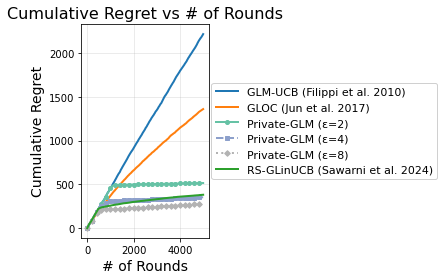

In [14]:
algo_names_list = ['RS-GLinUCB', 'GLM-UCB', 'GLOC', 'Private-GLM']
num_trials = 10

regret_dict = simulate_with_epsilon(num_trials, env, algo_names_list, 0.02, epsilon_arr = [2, 4, 8], seed = 10345)
with open('./Results/experiment_probit_uniform_split.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Probit_Regret.png')